In [ ]:
import pandas as pd
from pathlib import Path

# Get all CSV files uploaded in Colab
csv_files = sorted(Path("/content").glob("*.csv"))

print(f"Found {len(csv_files)} CSV files")

for file in csv_files:
    print(file.name)

# Read and combine all CSV files
combined_df = pd.concat(
    [pd.read_csv(file) for file in csv_files],
    ignore_index=True
)

# Save combined file
combined_df.to_csv(
    "/content/metraq_aq_combined_2001_2024.csv",
    index=False
)

print("Files combined successfully!")
print(f"Combined dataset shape: {combined_df.shape}")

Found 24 CSV files
metraq_aq-2001.csv
metraq_aq-2002.csv
metraq_aq-2003.csv
metraq_aq-2004.csv
metraq_aq-2005.csv
metraq_aq-2006.csv
metraq_aq-2007.csv
metraq_aq-2008.csv
metraq_aq-2009.csv
metraq_aq-2010.csv
metraq_aq-2011.csv
metraq_aq-2012.csv
metraq_aq-2013.csv
metraq_aq-2014.csv
metraq_aq-2015.csv
metraq_aq-2016.csv
metraq_aq-2017.csv
metraq_aq-2018.csv
metraq_aq-2019.csv
metraq_aq-2020.csv
metraq_aq-2021.csv
metraq_aq-2022.csv
metraq_aq-2023.csv
metraq_aq-2024.csv
Files combined successfully!
Combined dataset shape: (53840659, 9)


In [ ]:
import pyspark

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

import pandas as pd
import matplotlib.pyplot as plt

spark = SparkSession.builder.appName("AirQualityKMeans").getOrCreate()

df = spark.read.csv(
    "/content/metraq_aq_combined_2001_2024.csv",
    header=True,
    inferSchema=True
)

df.printSchema()
df.show(5)

root
 |-- sensor_id: integer (nullable = true)
 |-- sensor_name: string (nullable = true)
 |-- utm_x: double (nullable = true)
 |-- utm_y: double (nullable = true)
 |-- magnitude_id: integer (nullable = true)
 |-- magnitude_name: string (nullable = true)
 |-- entry_date: string (nullable = true)
 |-- value: double (nullable = true)
 |-- is_interpolated: double (nullable = true)

+---------+---------------+-----------+-----------+------------+--------------+-------------------+-----+---------------+
|sensor_id|    sensor_name|      utm_x|      utm_y|magnitude_id|magnitude_name|         entry_date|value|is_interpolated|
+---------+---------------+-----------+-----------+------------+--------------+-------------------+-----+---------------+
| 28079004|Plaza de España|439579.3291|4475049.263|           1|           SO2|2001-01-01 00:00:00| 21.0|            0.0|
| 28079004|Plaza de España|439579.3291|4475049.263|           6|            CO|2001-01-01 00:00:00|  1.0|            0.0|
| 280790

In [ ]:
# Clean and prepare data
df_clean = df.select(
    "sensor_id",
    "sensor_name",
    "entry_date",
    "magnitude_name",
    "value"
).dropna()

df_clean = df_clean.withColumn("value", col("value").cast("double"))

# Pivot pollutants into columns
pivot_df = df_clean.groupBy(
    "sensor_id",
    "sensor_name",
    "entry_date"
).pivot("magnitude_name").agg(avg("value"))

pivot_df.show(5)


+---------+---------------+-------------------+-----+------+-------+---+----+-----------+-----------------------+------------------+----+------+----+-----+-----+----+------+----------+---------------+-------------+-------------------+----+-------------+----+----+------+----------+---------------+-------------+-------------------+----+------+----------+---------------+-------------+-------------------+-------+----+
|sensor_id|    sensor_name|         entry_date|<PM10|<PM2.5|BENCENO| CO|  DV|ETILBENCENO|HIDROCARBS_NO_METANICOS|HIDROCARBS_TOTALES|  HR|METANO|  NO|  NO2|  NOX|  O3|OC_IDW|OC_KRIGING|OC_RBF_GAUSSIAN|OC_RBF_LINEAR|OC_RBF_MULTIQUADRIQ| PRE|PRECIPITACION|  RS| SO2|SP_IDW|SP_KRIGING|SP_RBF_GAUSSIAN|SP_RBF_LINEAR|SP_RBF_MULTIQUADRIQ|TEMP|TI_IDW|TI_KRIGING|TI_RBF_GAUSSIAN|TI_RBF_LINEAR|TI_RBF_MULTICUADRIC|TOLUENO|  VV|
+---------+---------------+-------------------+-----+------+-------+---+----+-----------+-----------------------+------------------+----+------+----+-----+-----+---

In [ ]:
# Fill missing values
pivot_df = pivot_df.na.fill(0)

# Select numeric feature columns
feature_cols = [
    c for c, t in pivot_df.dtypes
    if t in ["int", "bigint", "double", "float"] and c != "sensor_id"
]

print(feature_cols)

['<PM10', '<PM2.5', 'BENCENO', 'CO', 'DV', 'ETILBENCENO', 'HIDROCARBS_NO_METANICOS', 'HIDROCARBS_TOTALES', 'HR', 'METANO', 'NO', 'NO2', 'NOX', 'O3', 'OC_IDW', 'OC_KRIGING', 'OC_RBF_GAUSSIAN', 'OC_RBF_LINEAR', 'OC_RBF_MULTIQUADRIQ', 'PRE', 'PRECIPITACION', 'RS', 'SO2', 'SP_IDW', 'SP_KRIGING', 'SP_RBF_GAUSSIAN', 'SP_RBF_LINEAR', 'SP_RBF_MULTIQUADRIQ', 'TEMP', 'TI_IDW', 'TI_KRIGING', 'TI_RBF_GAUSSIAN', 'TI_RBF_LINEAR', 'TI_RBF_MULTICUADRIC', 'TOLUENO', 'VV']


In [ ]:
from pyspark.sql.functions import col
import re

# Rename columns to safe names
def clean_col_name(name):
    return re.sub(r"[^a-zA-Z0-9_]", "_", name)

for old_name in pivot_df.columns:
    new_name = clean_col_name(old_name)
    pivot_df = pivot_df.withColumnRenamed(old_name, new_name)

pivot_df.printSchema()

root
 |-- sensor_id: integer (nullable = true)
 |-- sensor_name: string (nullable = true)
 |-- entry_date: string (nullable = true)
 |-- _PM10: double (nullable = false)
 |-- _PM2_5: double (nullable = false)
 |-- BENCENO: double (nullable = false)
 |-- CO: double (nullable = false)
 |-- DV: double (nullable = false)
 |-- ETILBENCENO: double (nullable = false)
 |-- HIDROCARBS_NO_METANICOS: double (nullable = false)
 |-- HIDROCARBS_TOTALES: double (nullable = false)
 |-- HR: double (nullable = false)
 |-- METANO: double (nullable = false)
 |-- NO: double (nullable = false)
 |-- NO2: double (nullable = false)
 |-- NOX: double (nullable = false)
 |-- O3: double (nullable = false)
 |-- OC_IDW: double (nullable = false)
 |-- OC_KRIGING: double (nullable = false)
 |-- OC_RBF_GAUSSIAN: double (nullable = false)
 |-- OC_RBF_LINEAR: double (nullable = false)
 |-- OC_RBF_MULTIQUADRIQ: double (nullable = false)
 |-- PRE: double (nullable = false)
 |-- PRECIPITACION: double (nullable = false)
 |--

In [ ]:
# Select numeric feature columns again after renaming
feature_cols = [
    c for c, t in pivot_df.dtypes
    if t in ["int", "bigint", "double", "float"] and c != "sensor_id"
]

print(feature_cols)

['_PM10', '_PM2_5', 'BENCENO', 'CO', 'DV', 'ETILBENCENO', 'HIDROCARBS_NO_METANICOS', 'HIDROCARBS_TOTALES', 'HR', 'METANO', 'NO', 'NO2', 'NOX', 'O3', 'OC_IDW', 'OC_KRIGING', 'OC_RBF_GAUSSIAN', 'OC_RBF_LINEAR', 'OC_RBF_MULTIQUADRIQ', 'PRE', 'PRECIPITACION', 'RS', 'SO2', 'SP_IDW', 'SP_KRIGING', 'SP_RBF_GAUSSIAN', 'SP_RBF_LINEAR', 'SP_RBF_MULTIQUADRIQ', 'TEMP', 'TI_IDW', 'TI_KRIGING', 'TI_RBF_GAUSSIAN', 'TI_RBF_LINEAR', 'TI_RBF_MULTICUADRIC', 'TOLUENO', 'VV']


In [ ]:
# Assemble features
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_raw"
)

assembled_df = assembler.transform(pivot_df)

# Scale features
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(assembled_df)
scaled_df = scaler_model.transform(assembled_df)

In [ ]:
# Faster Sensitivity Analysis using sample

sampled_df = scaled_df.sample(
    fraction=0.05,
    seed=42
).cache()

print("Sample count:", sampled_df.count())

evaluator = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="prediction",
    metricName="silhouette"
)

results = []

for k in range(2, 7):
    kmeans = KMeans(
        featuresCol="features",
        predictionCol="prediction",
        k=k,
        seed=42,
        maxIter=5
    )

    model = kmeans.fit(sampled_df)
    predictions = model.transform(sampled_df)

    silhouette = evaluator.evaluate(predictions)
    inertia = model.summary.trainingCost

    results.append((k, inertia, silhouette))

results_df = pd.DataFrame(
    results,
    columns=["k", "inertia", "silhouette_score"]
)

display(results_df)

Sample count: 190380


,k,inertia,silhouette_score
0,2,5.740075e+06,0.431690
1,3,5.273901e+06,0.367024
2,4,5.058226e+06,0.329772
3,5,4.692051e+06,0.358248
4,6,4.328383e+06,0.406556


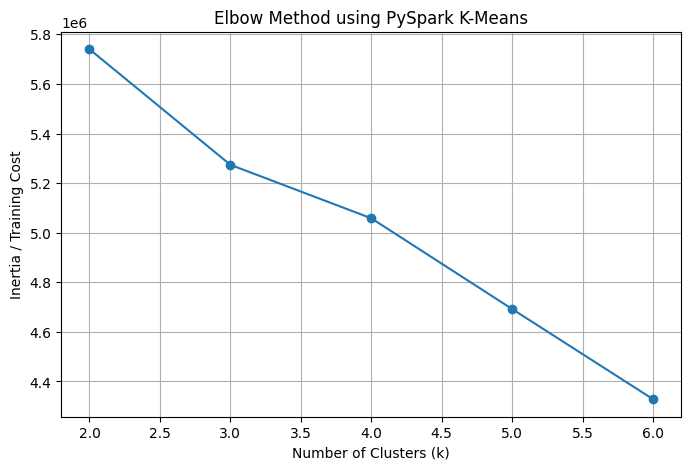

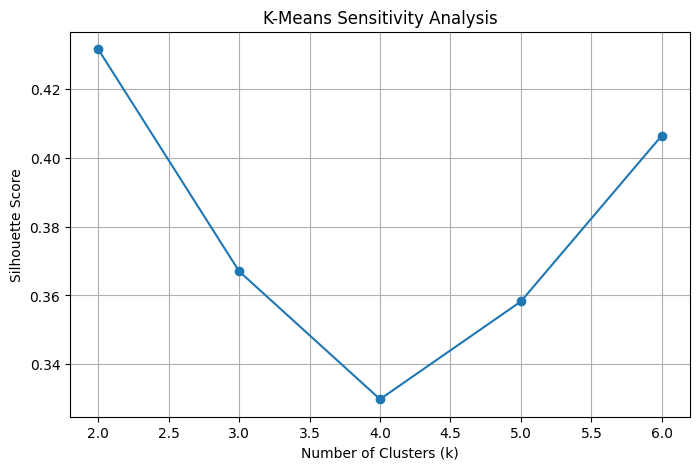

In [ ]:
# Plot Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(results_df["k"], results_df["inertia"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia / Training Cost")
plt.title("Elbow Method using PySpark K-Means")
plt.grid(True)
plt.show()

# Plot Silhouette Score
plt.figure(figsize=(8, 5))
plt.plot(results_df["k"], results_df["silhouette_score"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Sensitivity Analysis")
plt.grid(True)
plt.show()

In [ ]:
# Choose best k
best_k = int(results_df.loc[results_df["silhouette_score"].idxmax(), "k"])
print("Best k:", best_k)

Best k: 2


In [ ]:
# Final K-Means Model
kmeans = KMeans(
    featuresCol="features",
    predictionCol="cluster",
    k=best_k,
    seed=42
)

kmeans_model = kmeans.fit(scaled_df)
clustered_df = kmeans_model.transform(scaled_df)

clustered_df.select(
    "sensor_id",
    "sensor_name",
    "entry_date",
    "cluster"
).show(10)

In [ ]:
# PCA for visualization
pca = PCA(
    k=2,
    inputCol="features",
    outputCol="pca_features"
)

pca_model = pca.fit(clustered_df)
pca_df = pca_model.transform(clustered_df)

# Convert only sample to Pandas for plotting
plot_df = pca_df.select("pca_features", "cluster").sample(
    fraction=0.05,
    seed=42
).toPandas()

plot_df["PC1"] = plot_df["pca_features"].apply(lambda x: float(x[0]))
plot_df["PC2"] = plot_df["pca_features"].apply(lambda x: float(x[1]))

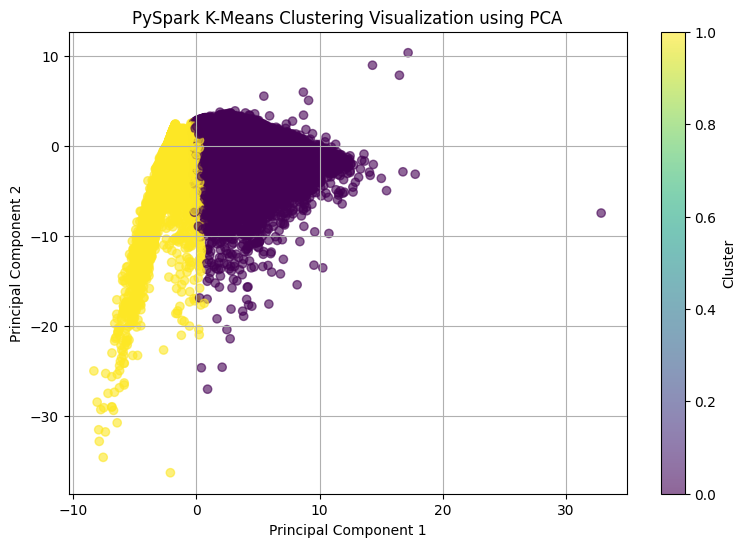

In [ ]:
# K-Means Visualization
plt.figure(figsize=(9, 6))
plt.scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    c=plot_df["cluster"],
    alpha=0.6
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PySpark K-Means Clustering Visualization using PCA")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

In [ ]:
# Cluster Summary
cluster_summary = clustered_df.groupBy("cluster").agg(
    *[avg(c).alias(f"avg_{c}") for c in feature_cols]
)

cluster_summary.show()

+-------+------------------+------------------+-------------------+--------------------+-------------------+-------------------+---------------------------+----------------------+-------------------+-------------------+------------------+-----------------+-----------------+------------------+-------------------+-------------------+--------------------+-------------------+-----------------------+-----------------+--------------------+------------------+------------------+------------------+------------------+--------------------+------------------+-----------------------+-------------------+------------------+------------------+--------------------+------------------+-----------------------+------------------+--------------------+
|cluster|         avg__PM10|        avg__PM2_5|        avg_BENCENO|              avg_CO|             avg_DV|    avg_ETILBENCENO|avg_HIDROCARBS_NO_METANICOS|avg_HIDROCARBS_TOTALES|             avg_HR|         avg_METANO|            avg_NO|          avg_NO2|    

In [ ]:
# Cluster Stability Analysis
base_model = KMeans(
    featuresCol="features",
    predictionCol="base_cluster",
    k=best_k,
    seed=42
).fit(scaled_df)

base_predictions = base_model.transform(scaled_df).select(
    "sensor_id",
    "entry_date",
    "base_cluster"
)

stability_results = []

for seed in [0, 10, 20, 30, 40, 50]:
    temp_model = KMeans(
        featuresCol="features",
        predictionCol="temp_cluster",
        k=best_k,
        seed=seed
    ).fit(scaled_df)

    temp_predictions = temp_model.transform(scaled_df).select(
        "sensor_id",
        "entry_date",
        "temp_cluster"
    )

    joined = base_predictions.join(
        temp_predictions,
        on=["sensor_id", "entry_date"],
        how="inner"
    )

    agreement = joined.filter(
        col("base_cluster") == col("temp_cluster")
    ).count() / joined.count()

    stability_results.append((seed, agreement))

stability_df = pd.DataFrame(
    stability_results,
    columns=["random_seed", "cluster_agreement"]
)

display(stability_df)

NameError: name 'KMeans' is not defined

In [ ]:
# Plot Cluster Stability
plt.figure(figsize=(8, 5))
plt.plot(
    stability_df["random_seed"],
    stability_df["cluster_agreement"],
    marker="o"
)
plt.xlabel("Random Seed")
plt.ylabel("Cluster Agreement")
plt.title("Cluster Stability Across Random Seeds")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

NameError: name 'plt' is not defined